In [1]:
pip install torch pandas numpy scikit-learn

In [2]:
import pandas as pd
import numpy as np

df_train = pd.read_csv("/content/spectral_graffiti_headley_recovered[1].csv")

df_train = df_train.sort_values(["Sample_ID","Time_ms"])

samples = []

for sid,g in df_train.groupby("Sample_ID"):

    g = g.sort_values("Time_ms")

    t = g["Time_ms"].values.astype(np.float32)
    v = g["Value"].values.astype(np.float32)
    m = g["Is_Context"].values.astype(np.int32)

    samples.append((sid,t,v,m))

FileNotFoundError: [Errno 2] No such file or directory: '/content/spectral_graffiti_headley_recovered[1].csv'

In [2]:
def split_context(mask):

    context_ids = np.where(mask==1)[0]

    train_ids = np.random.choice(context_ids,15,replace=False)

    val_ids = np.array(list(set(context_ids)-set(train_ids)))

    train_mask = np.zeros_like(mask)
    train_mask[train_ids] = 1

    return train_mask,val_ids

In [3]:
import torch
from torch.utils.data import Dataset

class SpectralDataset(Dataset):

    def __init__(self,samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self,idx):

        sid,t,v,m = self.samples[idx]

        train_mask,val_ids = split_context(m)

        input_value = v * train_mask

        return {
            "time": torch.tensor(t),
            "value": torch.tensor(v),
            "train_mask": torch.tensor(train_mask),
            "val_ids": torch.tensor(val_ids)
        }

In [4]:
import torch

def fourier_embedding(t, dim=48):

    device = t.device

    freqs = torch.arange(dim//2, device=device).float()

    angles = t.unsqueeze(-1) * freqs

    emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)

    return emb

In [5]:
import torch.nn as nn

class SpectralTransformer(nn.Module):

    def __init__(self,d_model=128):

        super().__init__()

        self.time_proj = nn.Linear(48,d_model)
        self.value_proj = nn.Linear(1,d_model)
        self.mask_embed = nn.Embedding(2,d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=256,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=4
        )

        self.out = nn.Linear(d_model,1)

    def forward(self,t,v,m):

        t_emb = self.time_proj(fourier_embedding(t))
        v_emb = self.value_proj(v.unsqueeze(-1))
        m_emb = self.mask_embed(m.long())

        x = t_emb + v_emb + m_emb

        x = self.encoder(x)

        pred = self.out(x).squeeze(-1)

        return pred

In [6]:
def reconstruction_loss(pred,true,val_ids):

    loss = 0

    for i in range(len(val_ids)):

        ids = val_ids[i]

        loss += ((pred[i,ids] - true[i,ids])**2).mean()

    return loss/len(val_ids)

In [7]:
def smoothness_loss(pred):

    return ((pred[:,2:] - 2*pred[:,1:-1] + pred[:,:-2])**2).mean()

In [8]:
def anchor_loss(pred, true, mask):

    anchor_ids = mask == 1

    return ((pred[anchor_ids] - true[anchor_ids])**2).mean()

In [ ]:
from torch.utils.data import DataLoader

dataset = SpectralDataset(samples)

loader = DataLoader(dataset,batch_size=32,shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SpectralTransformer().to(device)

opt = torch.optim.Adam(model.parameters(),lr=1e-3)

for epoch in range(25):

    total = 0

    for batch in loader:

        t = batch["time"].to(device)
        v = batch["value"].to(device)
        mask = batch["train_mask"].to(device)
        val_ids = batch["val_ids"]

        pred = model(t,v*mask,mask)

        loss = reconstruction_loss(pred,v,val_ids)

        loss += 0.15*smoothness_loss(pred)

        loss += 0.6*anchor_loss(pred,v,mask)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print("epoch",epoch,total/len(loader))

In [9]:
def predict_sample(model, sample):

    device = next(model.parameters()).device

    sid, t, v, m = sample

    t = torch.tensor(t).unsqueeze(0).to(device)
    v = torch.tensor(v).unsqueeze(0).to(device)
    m = torch.tensor(m).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(t, v * m, m)

    return pred[0].cpu().numpy()

In [ ]:
predictions = []

model.eval()

for sample in samples:

    sid, t, v, m = sample

    pred = predict_sample(model, sample)

    predictions.append((sid, t, pred))

In [10]:
import matplotlib.pyplot as plt

def plot_sample(sample,model):

    sid,t,v,m = sample

    pred = predict_sample(model,sample)

    plt.figure(figsize=(10,5))

    plt.scatter(t[m==1],v[m==1],color="green",label="context")

    plt.plot(t,pred,color="blue",label="prediction")

    plt.xlabel("Time (ms)")
    plt.ylabel("Signal")

    plt.title(f"Sample {sid}")

    plt.legend()

    plt.show()

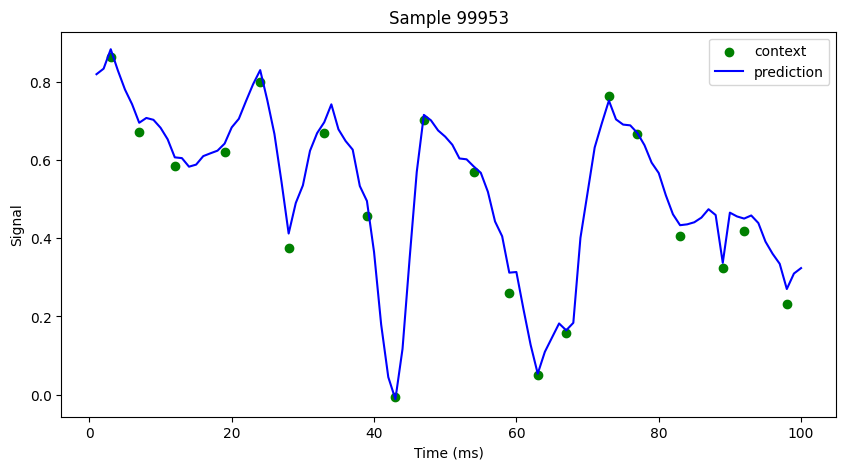

In [31]:
plot_sample(samples[9953],model)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import torch

def plot_sample_spline(sample_id, samples, model):

    model.eval()

    device = next(model.parameters()).device

    # find sample
    sample = None
    for s in samples:
        if s[0] == sample_id:
            sample = s
            break

    if sample is None:
        print("Sample not found")
        return

    sid, t, v, m = sample

    # convert to tensors
    t_tensor = torch.tensor(t).unsqueeze(0).to(device)
    v_tensor = torch.tensor(v).unsqueeze(0).to(device)
    m_tensor = torch.tensor(m).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(t_tensor, v_tensor*m_tensor, m_tensor)

    pred = pred[0].cpu().numpy()

    # spline interpolation for visualization
    spline = CubicSpline(t, pred)

    t_dense = np.linspace(t.min(), t.max(), 500)
    pred_smooth = spline(t_dense)

    plt.figure(figsize=(10,5))

    # context points
    plt.scatter(
        t[m==1],
        v[m==1],
        color="green",
        label="context points",
        zorder=3
    )

    # raw predictions
    plt.scatter(
        t,
        pred,
        color="blue",
        s=15,
        alpha=0.5,
        label="predicted points"
    )

    # smooth spline curve
    plt.plot(
        t_dense,
        pred_smooth,
        color="red",
        linewidth=2,
        label="spline (visualization)"
    )

    plt.title(f"Sample {sample_id}")
    plt.xlabel("Time (ms)")
    plt.ylabel("Signal Value")

    plt.legend()
    plt.show()

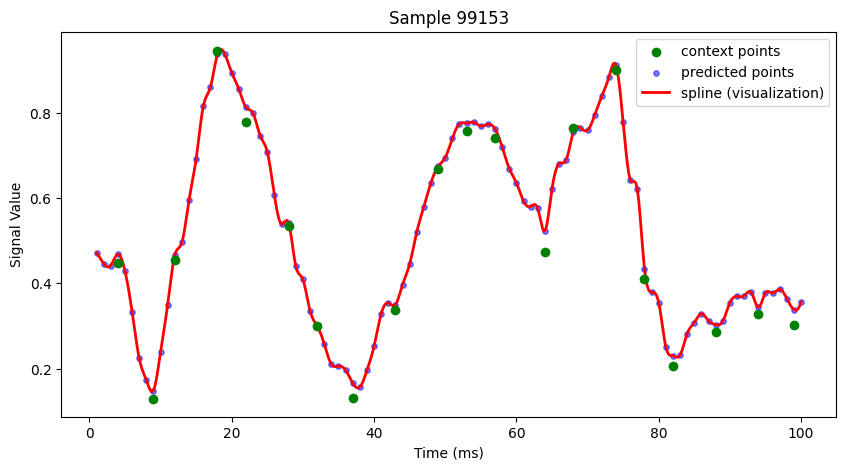

In [32]:
plot_sample_spline(99153, samples, model)

In [ ]:
torch.save(model.state_dict(), "best_model_spectral_bridge.pth")

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SpectralTransformer()

model.load_state_dict(torch.load("/content/best_model_spectral_bridge (1).pth", map_location=device))

model.to(device)

model.eval()

SpectralTransformer(
  (time_proj): Linear(in_features=48, out_features=128, bias=True)
  (value_proj): Linear(in_features=1, out_features=128, bias=True)
  (mask_embed): Embedding(2, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (out): Linear(in_features=128, out_features=1, bias=True)
)

In [13]:
import pandas as pd
df = pd.read_csv("/content/test_features_spectral - test_features_spectral.csv", usecols = [0,1,2,3])

In [14]:
len(df)

1070369

In [15]:
df = df[df["Is_Context"].isin([0,1])]
df["Is_Context"].nunique()

2

In [16]:

import numpy as np

predictions = []

for sid, group in df.groupby("Sample_ID"):

    group = group.sort_values("Time_ms")

    t = group["Time_ms"].values.astype(np.float32)
    v = group["Value"].values.astype(np.float32)
    m = group["Is_Context"].values.astype(np.float32)

    t_tensor = torch.tensor(t).unsqueeze(0).to(device)
    v_tensor = torch.tensor(v).unsqueeze(0).to(device)
    m_tensor = torch.tensor(m).unsqueeze(0).to(device)

    with torch.no_grad():

        pred = model(t_tensor, v_tensor*m_tensor, m_tensor)

    pred = pred.cpu().numpy()[0]

    group["Predicted_Value"] = pred

    predictions.append(group)

In [17]:
pred_df = pd.concat(predictions)

In [18]:
submission = pred_df[
    ["Sample_ID", "Time_ms", "Predicted_Value"]
]

In [22]:
submission.to_csv("submission.csv", index=False)

In [23]:
pd.read_csv("/content/submission.csv").head()

,Sample_ID,Time_ms,Predicted_Value
0,90000,1,0.326538
1,90000,2,0.338115
2,90000,3,0.328983
3,90000,4,0.288068
4,90000,5,0.295027


In [19]:
import pandas as pd
import numpy as np

df = df.sort_values(["Sample_ID","Time_ms"])

samples = []

for sid,g in df.groupby("Sample_ID"):

    g = g.sort_values("Time_ms")

    t = g["Time_ms"].values.astype(np.float32)
    v = g["Value"].values.astype(np.float32)
    m = g["Is_Context"].values.astype(np.int32)

    samples.append((sid,t,v,m))